# Modelatge
En aquest notebook aplicarem models d'aprenentatge no supervisats de clustering per agrupar els barris segons les seves característiques. 

**to do**
-  Preprocess
    - Log Transf\
Tal i com hem comentat en eda, algunes variables amb valor absoluts, presenten valors extrems. Per tal de reduir el seu efecte en clustering, aplicarem transformacions logarítmiques.
        - df_2015:
            - total_incidents_1000_hab
            - locals_restauracio_1000_hab
        - df_2023:
            - total_incidents_1000_hab
            - locals_serveis_professionals_1000_hab

    - Winsorization\
En relació als valors extrems esmentats anteriorment, els deltes calculats a partir d'aquests també queden exposats a aquest efecte. Dondad la naturalesa de les variacions (-inf, +inf) no podem aplicar transformació logarítmica directament. Per tant aplicarem tècnica de windsorization, per capar els valors extrems i imputar-los amb uns valors menys extrems (98%).
        - df_deltes
            - delta_locals_serveis_professionals_1000_hab
            - delta_pisos_turistics_1000_hab
            - delta_poblacio_total (tbc)

-  StandardScaler
-  PCA
-  Models
    - Kmeans
    - AglomerativeClustering

- Conclusions i resultats

**Funcions a definir:**
- funcio per aplicar transf logarítmica a certes variables
- funcio per aplicar winsoring
- funcio per gràficar pca i variança explicada
- funcio per silouette i inercia
- funcio per kmeans i graficar clusters
- funcio per agglomerative i graficar clusters
- funcio per els clusters en mapa






# Llibreries i configuracio

In [71]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from shapely import wkt
import geopandas as gpd


# Evitar warning
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme()

# Carrega dels datasets

In [47]:
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR/'data'
RESULTS_DIR = BASE_DIR/'results'/'figs'


df_2015 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2015.csv')
df_2023 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2023.csv')
df_deltes = pd.read_csv(DATA_DIR / 'modelling' / 'df_deltes.csv')

dim_barris = pd.read_csv(DATA_DIR / 'dimensions' / 'BarcelonaCiutat_Barris.csv')

print("Dataset 2015: ", df_2015.shape)
print("Dataset 2023: ", df_2023.shape)
print("Dataset Deltes: ", df_deltes.shape)

Dataset 2015:  (73, 14)
Dataset 2023:  (73, 14)
Dataset Deltes:  (73, 14)


# Funcions auxiliars 

In [77]:
def transformacio_logaritmica(df: pd.DataFrame, columnes: list):
    df_mod = df.copy()
    for c in columnes:
        if (df_mod[c] < 0).any():
            raise ValueError(f"La columna {c} té valors negatius. No es pot aplicar log1p.")
        
        df_mod[c] = np.log1p(df_mod[c])
    return df_mod

def transformacio_winsor(df: pd.DataFrame, columnes: list, low: float, high: float):
    df_mod = df.copy()
    for c in columnes:
        lower = df_mod[c].quantile(low)
        upper = df_mod[c].quantile(high)
        
        df_mod[c] = df_mod[c].clip(lower, upper)
    
    return df_mod

def extreure_codi_barri(df:pd.DataFrame): 
    codi_barri = df["codi_barri"]
    X = df[[col for col in df.columns if col != "codi_barri"]].copy()
    return codi_barri, X


def grafic_var_explicada(pca: np.array, target: float, titol: str, nom_arxiu: str):
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumsum >= target) + 1
    var_explicada = pca.explained_variance_ratio_
    
    plt.figure(figsize=(6,3))
    plt.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.6, label="Var Explicada")
    plt.plot(range(1, len(var_explicada)+1), cumsum, linewidth=1, marker = 'o', label= "Var Explicada Cum",c ="r")
    plt.axhline(0.95, color='green', linestyle='--', label='95%')
    plt.plot([n_components, n_components], [0, target], "k:")
    plt.plot([0, n_components], [target, target], "k:")
    plt.plot(n_components, target, "ko")
    plt.xlabel("Dimensions")
    plt.ylabel("Explained Variance")
    plt.title(f"{titol} | n_components = {n_components}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_arxiu}")
    plt.show()


def evaluacio_cluster(clusterer: KMeans, X: np.array, labels: np.array, nom_model: str, tipo_dades: str):
    resultats = {
        "model": nom_model,
        "tipo_dades": tipo_dades,
        "n_clusters" : len(set(labels))
    }

    resultats["silhouette"] = silhouette_score(X, labels)
    
    if isinstance(clusterer, KMeans):  # inercia només per kmeans
        resultats["inercia"] = clusterer.inertia_
    
    
    return resultats

def plot_seleccio_kmeans(results: pd.DataFrame, nom_dades: str, nom_fitxer: str):
    fig = plt.figure(figsize=(8, 5))
    ax1 = fig.add_subplot(2, 1, 1)
    ax2 = fig.add_subplot(2, 1, 2)
    sns.lineplot(results, y = "inercia", x = "n_clusters", hue = "tipo_dades", ax=ax1, style="tipo_dades", markers=['o', 'D'])
    sns.lineplot(results, y = "silhouette", x = "n_clusters", hue = "tipo_dades", ax= ax2, style="tipo_dades", markers = ['o', 'D'])
    plt.suptitle(f"Selecció de k amb KMeans ({nom_dades})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()

def plot_seleccio_agg(results: pd.DataFrame, nom_dades: str, nom_fitxer: str):
    plt.figure(figsize=(8, 3))
    sns.lineplot(results, y = "silhouette", x = "n_clusters", hue = "tipo_dades", style="tipo_dades", markers = ['o', 'D'])
    plt.title(f"Selecció de K amb Silhouette amb Agglomerative Clustering ({nom_dades})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()




def plot_clusters(df: pd.DataFrame, titol: str, nom_fitxer: str, dir: str=RESULTS_DIR):
    dim_barris["geometry"] = dim_barris["geometria_wgs84"].apply(wkt.loads)
    gdf = gpd.GeoDataFrame(dim_barris, geometry="geometry", crs="EPSG:4326")
    gdf = gdf.merge(df[["codi_barri", "cluster"]], on="codi_barri", how="left")
    gdf.plot(
        column="cluster",
        categorical=True,
        legend=True,
        figsize=(8, 8),
        edgecolor="black",
        cmap="Accent",
        linewidth=0.3
    )
    plt.title(titol)
    plt.axis("off")
    plt.savefig(dir / f"{nom_fitxer}")
    plt.show()

# Preprocessament Comuns
- Separar variables de codi_barri
- Aplicar transformacions per outliers (logs o winsor)
- Escalar els conjunts de dades
- Aplicar PCA
- Aplicar clustering amb pca i amb escalat
- Seleccionar nombre de clusters
- Interpretació dels clústers

In [4]:
# Separem la columna de codi barri
codi_barri_15, X_15 = extreure_codi_barri(df_2015)
codi_barri_23, X_23 = extreure_codi_barri(df_2023)
codi_barri_deltes, X_deltes = extreure_codi_barri(df_deltes)

In [7]:
logs_2015 = ["total_incidents_1000_hab","locals_restauracio_1000_hab"]
logs_2023 = ["total_incidents_1000_hab", "locals_serveis_professionals_1000_hab"]
caps_deltes = ["delta_locals_serveis_professionals_1000_hab", "delta_pisos_turistics_1000_hab", "delta_poblacio_total"]

X_15_logs = transformacio_logaritmica(X_15, logs_2015)
X_23_logs = transformacio_logaritmica(X_23, logs_2023)
X_deltes_logs = transformacio_winsor(X_deltes, caps_deltes, 0.2, 0.98)

In [9]:
# Escalem les dades
scaler = StandardScaler()

X_15_scaled = scaler.fit_transform(X_15_logs)
X_23_scaled = scaler.fit_transform(X_23_logs)
X_deltes_scaled = scaler.fit_transform(X_deltes_logs)

# Dades 2015

## PCA (Principal Component analysis)

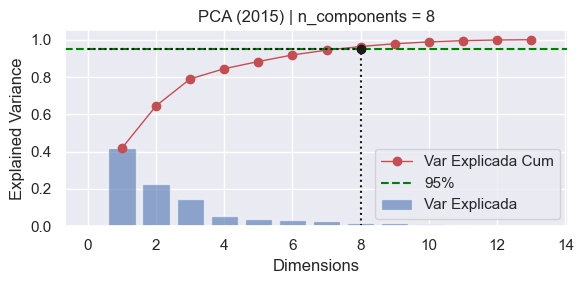

In [10]:
# Probarem PCA per reduir la dimensionalitat del conjunt de dades
pca_15 = PCA(random_state= 42)
pca_embedding = pca_15.fit_transform(X_15_scaled)
grafic_var_explicada(pca_15, 0.95, "PCA (2015)", "variança_explicada_15.png")

**Observacions:**
- 8 components per explicar el 95% de la variança de les dades. 
- Els tres principals components ja expliquen el 80% de la variança.

In [34]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_15 = np.argmax(np.cumsum(pca_15.explained_variance_ratio_) > 0.95) + 1

pca_15_fixed = PCA(n_components= n_components_15, random_state= 42)
X_pca_15_fixed = pca_15_fixed.fit_transform(X_15_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_15_fixed, columns=[f'PC{i}' for i in range(1, n_components_15 + 1)], index=df_2015['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,2.394009,4.551549,-1.515259,-2.319701,-0.199694,-0.956043,-0.042642,-0.262777
2,4.660526,6.204773,1.416379,-0.214522,-0.299504,0.124399,1.004626,-0.431889
3,2.745476,3.621419,1.370914,-0.257690,0.378690,-1.440013,1.603773,1.508977
4,4.263242,4.804871,0.842041,-0.365299,-0.335171,-1.050842,0.424999,-0.024162
5,1.967797,0.485187,-0.753469,0.790520,0.604716,0.161401,-0.657244,-0.241522


## Anàisi components PCA

## KMeans

In [35]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_2015 = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_15_scaled)
    resultats_clusters_2015.append(evaluacio_cluster(clusterer_scaled, X_15_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_15_fixed)
    resultats_clusters_2015.append(evaluacio_cluster(clusterer_pca, X_pca_15_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_2015_df = pd.DataFrame(resultats_clusters_2015)
resultats_2015_df

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.291655,646.724781
1,KMeans_2,pca,2,0.303156,612.291648
2,KMeans_3,escalades,3,0.309027,523.669004
3,KMeans_3,pca,3,0.322967,489.282094
4,KMeans_4,escalades,4,0.290372,446.282843
5,KMeans_4,pca,4,0.307173,411.973114
6,KMeans_5,escalades,5,0.257107,368.391474
7,KMeans_5,pca,5,0.284329,334.970196
8,KMeans_6,escalades,6,0.242146,335.508731
9,KMeans_6,pca,6,0.266021,301.026980


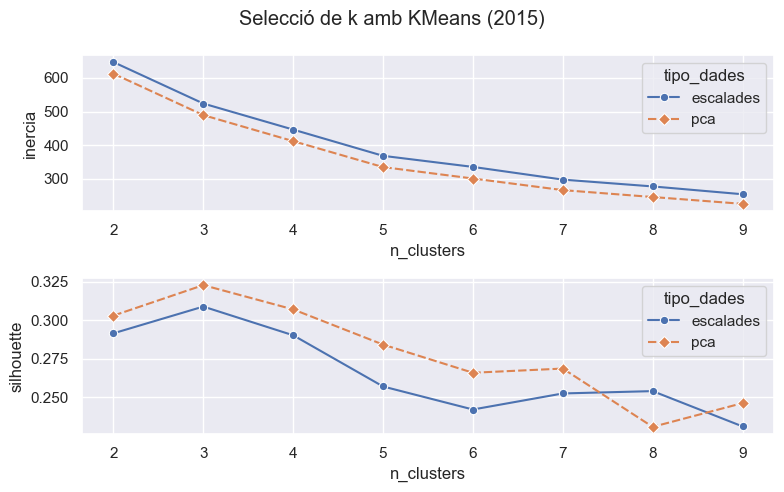

In [36]:
plot_seleccio_kmeans(resultats_2015_df, "2015", "seleccio_k_2015.png")

**Observacions:**
- El nombre òptim de clusters segons el valor de silhouette és 3, encara que amb 4 cluster s' obté un resultat força bai,x
- Els valors de silhouette són fluixos, indicant que els clusters no seran tant diferenciats.
- Els resultats milloren lleugerament amb pca.

## Agglomerative Clustering

In [37]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
agg_resultats_15 = []
for k in valors_k:
    agg_scaled = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_scaled.fit_predict(X_15_scaled)
    agg_resultats_15.append(evaluacio_cluster(agg_scaled, X_15_scaled, agg_labels, f"Agglomeratiu_{k}", "escalades"))

    agg_pca = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_pca.fit_predict(X_pca_15_fixed)
    agg_resultats_15.append(evaluacio_cluster(agg_pca, X_pca_15_fixed, agg_labels, f"Agglomeratiu_{k}", "pca"))


# Convertim a dataframe
agg_resultats_15_df = pd.DataFrame(agg_resultats_15)
agg_resultats_15_df

,model,tipo_dades,n_clusters,silhouette
0,Agglomeratiu_2,escalades,2,0.291655
1,Agglomeratiu_2,pca,2,0.307424
2,Agglomeratiu_3,escalades,3,0.309027
3,Agglomeratiu_3,pca,3,0.323764
4,Agglomeratiu_4,escalades,4,0.291629
5,Agglomeratiu_4,pca,4,0.187225
6,Agglomeratiu_5,escalades,5,0.252424
7,Agglomeratiu_5,pca,5,0.208987
8,Agglomeratiu_6,escalades,6,0.219023
9,Agglomeratiu_6,pca,6,0.218996


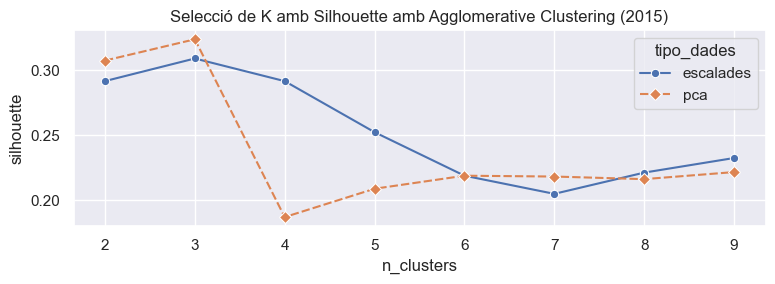

In [38]:
plot_seleccio_agg(agg_resultats_15_df, "2015", "seleccio_k_2015_agg.png")

**Observacions:**
- Scores de silhouette similars a les obtingudes amb KMeans, i amb millor score amb k=3, encara que k=2 obté resultats similars. 
- En aquest cas també, pca obté resultats lleugerament superiors. 

## Decisió i conclusions

In [76]:
conclusions_df23 = {"clusters": "k=3", 
                    "model": "kmeans",
                    "tipo_dades": "pca",
                    "comentari": "Tant per a KMeans com Agglomerative, i amb mètode de colze i valors de silhouette, el nombre òptim de cluster és k=3. Utilitzarem kmeans per interpretabilitat i coneixements ja que Agglomerative no millora substancialment el clustering."}

pd.DataFrame([conclusions_df23])

,clusters,model,tipo_dades,comentari
0,k=3,kmeans,pca,"Tant per a KMeans com Agglomerative, i amb mèt..."


## Clustering

In [ ]:
# Apliquem kmeans
k_15 = 3
kmeans_15_final = KMeans(n_clusters= k_15, random_state= 42, n_init = 20)
kmeans_15_final_labels = kmeans_15_final.fit_predict(X_pca_15_fixed)

# Obtenim codi de barri i cluster
clustered = df_2015[["codi_barri"]].copy()
clustered['cluster'] = kmeans_15_final_labels
clustered.head()


Distribucins de clusters:
 cluster
1    39
0    30
2     4
Name: count, dtype: int64


In [46]:
# Obtenim info dels clusters 
print("Distribucins de clusters:\n", clustered["cluster"].value_counts() )
print("\nPerfils: ")
perfils_15 = df_2015.merge(clustered, on = "codi_barri", how = "right")
perfils_15.groupby("cluster").mean().T


Distribucins de clusters:
 cluster
1    39
0    30
2     4
Name: count, dtype: int64

Perfils: 


cluster,0,1,2
codi_barri,27.766667,47.641026,2.500000
poblacio_total,29412.100000,15953.025641,25042.250000
pct_pob_estrangera,0.154681,0.132063,0.401387
pct_pob_estrangera_occidental,0.065206,0.023376,0.162695
pct_joves,0.274368,0.263019,0.399800
pct_universitaris,0.325844,0.138924,0.264166
import_euros,17606.942503,11723.282530,10615.768038
index_gini,35.206536,31.151871,37.973881
total_incidents_1000_hab,23.342094,52.498300,30.457174
locals_restauracio_1000_hab,6.330069,3.117782,19.001463


In [50]:
barris_clusters_15 = dim_barris[["codi_barri", "nom_barri"]].copy()
barris_clusters_15_merged = barris_clusters_15.merge(clustered, on = "codi_barri", how = "left")

for c in set(barris_clusters_15_merged["cluster"]):
    print(f"\nBarris en cluster {c}:")
    print(barris_clusters_15_merged["nom_barri"][barris_clusters_15_merged["cluster"] == c].unique())
    print("*"*50)


Barris en cluster 0:
['el Fort Pienc' 'la Sagrada Família' "la Dreta de l'Eixample"
 "l'Antiga Esquerra de l'Eixample" "la Nova Esquerra de l'Eixample"
 'Sant Antoni' 'el Poble-sec' 'la Font de la Guatlla' 'Hostafrancs'
 'Sants' 'les Corts' 'la Maternitat i Sant Ramon' 'Pedralbes'
 'Vallvidrera, el Tibidabo i les Planes' 'Sarrià' 'les Tres Torres'
 'Sant Gervasi - la Bonanova' 'Sant Gervasi - Galvany'
 'el Putxet i el Farró' 'Vallcarca i els Penitents' 'la Salut'
 'la Vila de Gràcia' "el Camp d'en Grassot i Gràcia Nova"
 'el Baix Guinardó' 'el Guinardó' "el Camp de l'Arpa del Clot"
 'el Parc i la Llacuna del Poblenou' 'la Vila Olímpica del Poblenou'
 'el Poblenou' 'Diagonal Mar i el Front Marítim del Poblenou']
**************************************************

Barris en cluster 1:
['la Marina del Prat Vermell' 'la Marina de Port' 'la Bordeta'
 'Sants - Badal' 'el Coll' 'Can Baró' "la Font d'en Fargues" 'el Carmel'
 'la Teixonera' 'Sant Genís dels Agudells' 'Montbau' "la Vall d'Hebro

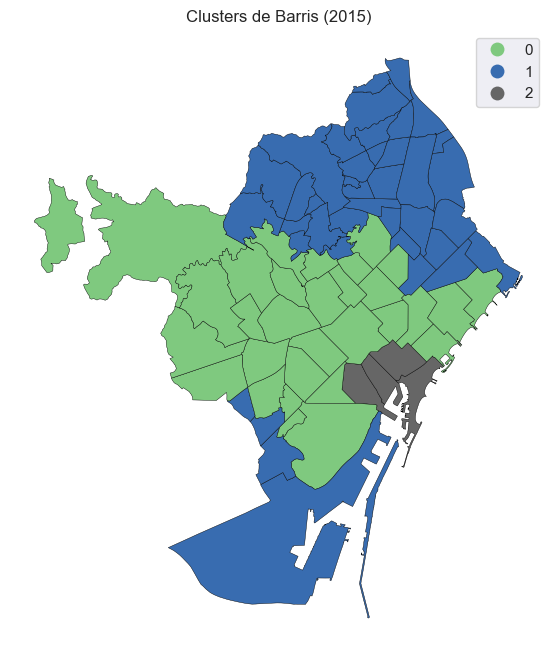

In [78]:
plot_clusters(clustered, "Clusters de Barris (2015)", "clusters_15.png")

# Dades 2023

## PCA (Principal Component Analysisi)

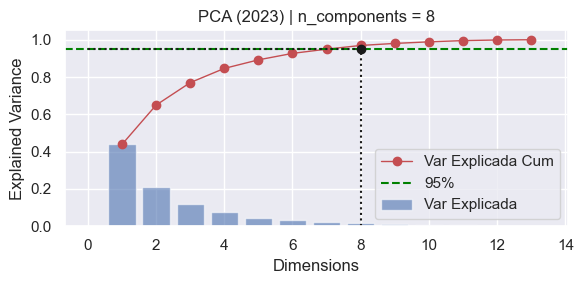

In [18]:
pca_23 = PCA(random_state= 42)
pca_embedding = pca_23.fit_transform(X_23_scaled)
grafic_var_explicada(pca_23, 0.95, "PCA (2023)", "variança_explicada_23.png")

**Observacions:**
- Per al dataset de 2023 el nombre de dimensions necessari per explicar el 95% de la variança són 8

In [19]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_23 = 8

pca_23_fixed = PCA(n_components= n_components_23, random_state= 42)
X_pca_23_fixed = pca_23_fixed.fit_transform(X_23_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_23_fixed, columns=[f'PC{i}' for i in range(1, n_components_23 + 1)], index=df_2023['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,2.279588,3.895755,0.532555,-1.569706,-0.439043,-0.896257,0.214921,-0.009310
2,4.617444,6.031876,-1.815871,-1.039161,-1.356210,-0.571358,0.530613,0.426491
3,3.060700,3.392185,-1.974732,0.106278,-0.163602,-0.581584,-1.488165,0.570237
4,4.674134,4.093708,-2.075445,-0.324293,-0.279745,-0.335467,-0.825599,-0.769719
5,2.118740,1.080636,0.494154,0.111880,0.864906,-0.080071,0.637641,-0.034132


## KMeans

In [20]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_2023 = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_23_scaled)
    resultats_clusters_2023.append(evaluacio_cluster(clusterer_scaled, X_23_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_23_fixed)
    resultats_clusters_2023.append(evaluacio_cluster(clusterer_pca, X_pca_23_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_2023_df = pd.DataFrame(resultats_clusters_2023)
resultats_2023_df

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.326887,634.605402
1,KMeans_2,pca,2,0.336898,605.731942
2,KMeans_3,escalades,3,0.319016,526.653853
3,KMeans_3,pca,3,0.307050,497.653525
4,KMeans_4,escalades,4,0.309884,450.638067
5,KMeans_4,pca,4,0.323041,421.924845
6,KMeans_5,escalades,5,0.226534,383.398273
7,KMeans_5,pca,5,0.239452,357.627443
8,KMeans_6,escalades,6,0.252278,344.144208
9,KMeans_6,pca,6,0.244193,314.819515


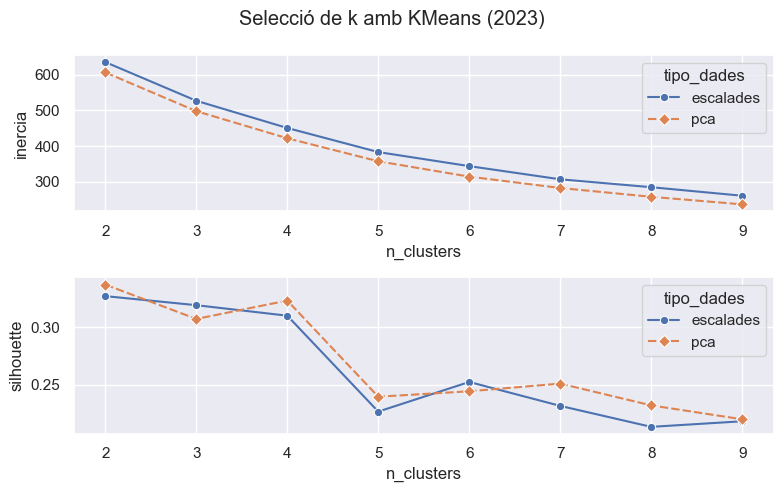

In [21]:
plot_seleccio_kmeans(resultats_2023_df, "2023", "seleccio_k_2023.png")

**Observacions:**
- Els resultats són lleugerament més bons amb les dades reduïdes. En aquest cas, el nombre de clúster òptim es veu molt clar en el gràfic de silhouette (5 clusters).


## Agglomerative Clustering

In [22]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
agg_resultats_23 = []
for k in valors_k:
    agg_scaled = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_scaled.fit_predict(X_23_scaled)
    agg_resultats_23.append(evaluacio_cluster(agg_scaled, X_23_scaled, agg_labels, f"Agglomeratiu_{k}", "escalades"))

    agg_pca = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_pca.fit_predict(X_pca_23_fixed)
    agg_resultats_23.append(evaluacio_cluster(agg_pca, X_pca_23_fixed, agg_labels, f"Agglomeratiu_{k}", "pca"))


# Convertim a dataframe
agg_resultats_23_df = pd.DataFrame(agg_resultats_23)
agg_resultats_23_df

,model,tipo_dades,n_clusters,silhouette
0,Agglomeratiu_2,escalades,2,0.317477
1,Agglomeratiu_2,pca,2,0.327630
2,Agglomeratiu_3,escalades,3,0.318167
3,Agglomeratiu_3,pca,3,0.329893
4,Agglomeratiu_4,escalades,4,0.308662
5,Agglomeratiu_4,pca,4,0.321221
6,Agglomeratiu_5,escalades,5,0.208448
7,Agglomeratiu_5,pca,5,0.230848
8,Agglomeratiu_6,escalades,6,0.226455
9,Agglomeratiu_6,pca,6,0.240337


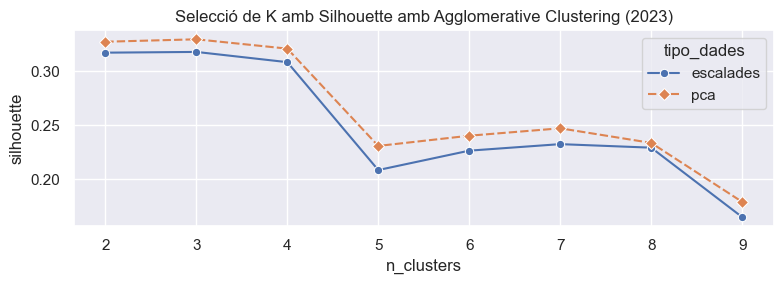

In [23]:
plot_seleccio_agg(agg_resultats_23_df, "2023", "seleccio_k_2023_agg.png")

**Observacions:**
- Nombre òptim de clusters es 5, tot i que amb 4 també s' obtenen bons resultats.
- El valor de silhouette amb k = 5 és lleugerament superior al obtingut amb KMeans.

## Deltes

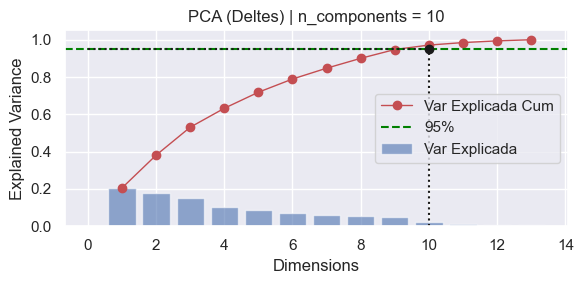

In [24]:
pca_deltes = PCA(random_state= 42)
pca_embedding = pca_deltes.fit_transform(X_deltes_scaled)
grafic_var_explicada(pca_deltes, 0.95, "PCA (Deltes)", "variança_explicada_deltes.png")

**Observacions:**
- Per al dataset de Deltes el nombre de dimensions necessari per explicar el 95% de la variança són 9 components

In [25]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_deltes = 10

pca_deltes_fixed = PCA(n_components= n_components_deltes, random_state= 42)
X_pca_deltes_fixed = pca_deltes_fixed.fit_transform(X_deltes_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_deltes_fixed, columns=[f'PC{i}' for i in range(1, n_components_deltes + 1)], index=df_deltes['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
codi_barri,,,,,,,,,,
1,0.950215,-0.378508,0.735759,0.704792,-0.959299,-0.330338,-0.520203,0.641753,0.091824,0.607451
2,-8.671105,-4.711258,-4.134759,0.040252,-1.338188,-1.932610,0.341121,0.912647,0.204339,0.722268
3,-0.266448,2.457091,0.054513,-1.131366,-1.236517,-1.428581,-2.315065,-0.738266,0.404131,0.007326
4,0.298924,0.963237,0.417405,-0.497372,-1.272486,-0.933344,-1.020689,-0.175130,0.434979,0.902859
5,-1.585780,1.288323,-0.311388,-0.278606,-0.973167,-0.947097,0.253401,-1.071558,0.137520,-0.406052


In [26]:
## KMeans
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_deltes = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_deltes_scaled)
    resultats_clusters_deltes.append(evaluacio_cluster(clusterer_scaled, X_deltes_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_deltes_fixed)
    resultats_clusters_deltes.append(evaluacio_cluster(clusterer_pca, X_pca_deltes_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_deltes_df = pd.DataFrame(resultats_clusters_deltes)
resultats_deltes_df

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.434347,820.177143
1,KMeans_2,pca,2,0.444867,793.188854
2,KMeans_3,escalades,3,0.128444,726.873997
3,KMeans_3,pca,3,0.136454,699.735153
4,KMeans_4,escalades,4,0.393735,626.134901
5,KMeans_4,pca,4,0.388545,600.954648
6,KMeans_5,escalades,5,0.121361,555.058182
7,KMeans_5,pca,5,0.138206,529.599469
8,KMeans_6,escalades,6,0.144314,495.296425
9,KMeans_6,pca,6,0.149519,471.625182


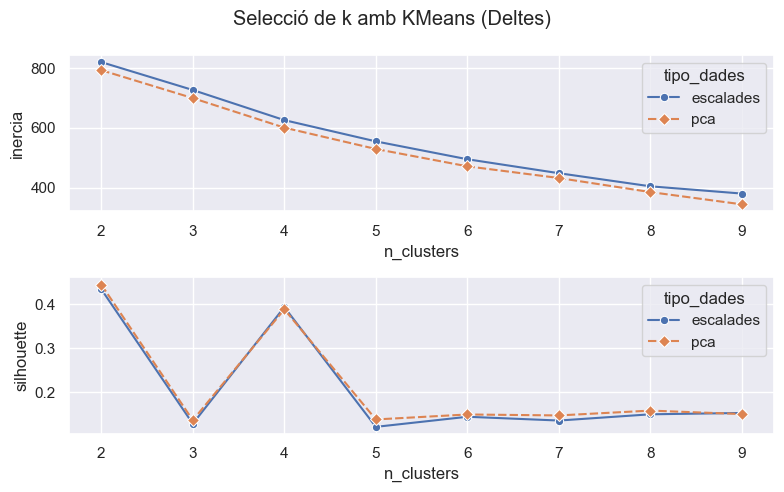

In [27]:
plot_seleccio_kmeans(resultats_deltes_df, "Deltes", "seleccio_k_deltes.png")

**Observacions:**
- Mentre que amb El mètode del colze, el nombre òptim de k és 4, en el gràfic dels valors de silhouette, k = 3 és el òptim, de fet k = 4 es redueix dràsticament el score. 

In [28]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
agg_resultats_deltes = []
for k in valors_k:
    agg_scaled = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_scaled.fit_predict(X_deltes_scaled)
    agg_resultats_deltes.append(evaluacio_cluster(agg_scaled, X_deltes_scaled, agg_labels, f"Aglomeratiu_{k}", "escalades"))

    agg_pca = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_pca.fit_predict(X_pca_deltes_fixed)
    agg_resultats_deltes.append(evaluacio_cluster(agg_pca, X_pca_deltes_fixed, agg_labels, f"Aglomeratiu_{k}", "pca"))


# Convertim a dataframe
agg_resultats_deltes_df = pd.DataFrame(agg_resultats_deltes)
agg_resultats_deltes_df

,model,tipo_dades,n_clusters,silhouette
0,Aglomeratiu_2,escalades,2,0.568910
1,Aglomeratiu_2,pca,2,0.599644
2,Aglomeratiu_3,escalades,3,0.545689
3,Aglomeratiu_3,pca,3,0.433052
4,Aglomeratiu_4,escalades,4,0.406839
5,Aglomeratiu_4,pca,4,0.438287
6,Aglomeratiu_5,escalades,5,0.097213
7,Aglomeratiu_5,pca,5,0.202895
8,Aglomeratiu_6,escalades,6,0.111014
9,Aglomeratiu_6,pca,6,0.086927


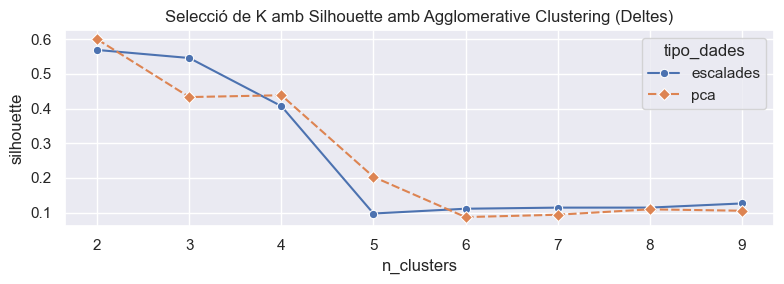

In [29]:
plot_seleccio_agg(agg_resultats_deltes_df, "Deltes", "seleccio_k_deltes_agg.png")

**Observacions:**
- Els resultats indiquen que el nombre de clusters optims per als deltes és de 2 o 3.
- Els resultats són similars a KMeans.